# Naive Bayes from Scratch

Two Naive Bayes classifiers built with NumPy only, trained on the UCI Spambase dataset (4601 emails, 57 features, binary spam / not-spam target).

`Gaussian_Naive_Bayes` models each feature as a normal distribution within each class. `Bernoulli_Naive_Bayes` binarises every feature at zero (word present / absent) and models each as a coin flip within each class. Both are fitted by counting: class priors and per-class per-feature statistics, computed in a single pass. There is no gradient descent, no learning rate, no epochs and no iterative optimisation of any kind. That is what separates Naive Bayes from every other model in this repository — the maximum-likelihood parameters have closed forms, so fitting is arithmetic over the training matrix and nothing more.

Prediction runs entirely in log space. Multiplying 57 probabilities together underflows to exactly `0.0` in float64; adding 57 logarithms does not. This is demonstrated concretely below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

BLUE = '#2a78d6'
ORANGE = '#eb6834'
GREEN = '#1baf7a'

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print('numpy', np.__version__)

numpy 1.26.4


## The data

`fetch_ucirepo(id=94)` returns the Spambase dataset. Each row is one email, summarised by 57 numbers:

- 48 `word_freq_*` columns: the percentage of words in the email that match a given word.
- 6 `char_freq_*` columns: the percentage of characters that match a given character.
- 3 `capital_run_length_*` columns: the average, longest and total length of runs of consecutive capital letters.

The target `Class` is 1 for spam and 0 for legitimate mail. The next cell downloads the data, converts the features to a float64 array `X` and the target to an integer vector `y`, and confirms there are no missing values.

In [2]:
spambase = fetch_ucirepo(id=94)

features_df = spambase.data.features
targets_df = spambase.data.targets

feature_names = list(features_df.columns)
X = features_df.values.astype(np.float64)
y = targets_df.values.ravel().astype(np.int64)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('missing values:', int(features_df.isna().sum().sum()))
print('classes:', np.unique(y))
print()
print(features_df.iloc[:4, :6])

X shape: (4601, 57)
y shape: (4601,)
missing values: 0
classes: [0 1]

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  
0           0.32            0.00  
1           0.14            0.28  
2           1.23            0.19  
3           0.63            0.00  


## Class balance

Roughly 39% of the emails are spam. The prior $P(y)$ is estimated directly from these counts:

$$P(y=c) = \frac{N_c}{N}$$

where $N_c$ is the number of training rows in class $c$ and $N$ the total. The bar chart below shows the raw counts for the full dataset.

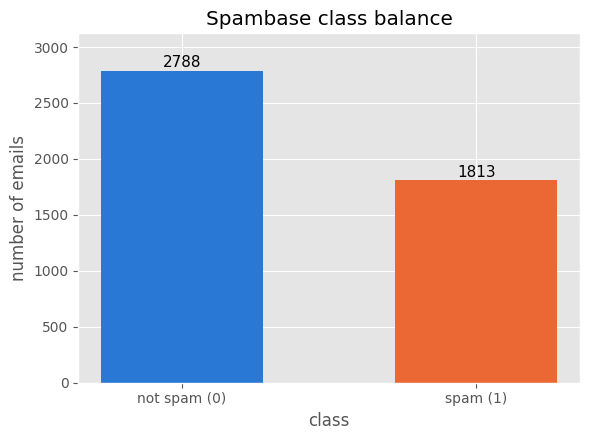

P(not spam) = 0.606
P(spam)     = 0.394


In [3]:
counts = np.array([np.sum(y == 0), np.sum(y == 1)])
labels = ['not spam (0)', 'spam (1)']

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, counts, color=[BLUE, ORANGE], width=0.55)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c + 30, str(c), ha='center', fontsize=11)
ax.set_title('Spambase class balance')
ax.set_xlabel('class')
ax.set_ylabel('number of emails')
ax.set_ylim(0, counts.max() * 1.12)
plt.tight_layout()
plt.show()

print('P(not spam) =', round(counts[0] / counts.sum(), 4))
print('P(spam)     =', round(counts[1] / counts.sum(), 4))

## Train / test split

A seeded permutation from `rng` splits the 4601 rows 80/20 into `X_train`, `y_train`, `X_test`, `y_test`. The same split is used for both classifiers so the comparison is fair.

In [4]:
perm = rng.permutation(X.shape[0])
n_train = int(0.8 * X.shape[0])
train_idx, test_idx = perm[:n_train], perm[n_train:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('train:', X_train.shape, ' spam fraction', round(y_train.mean(), 4))
print('test: ', X_test.shape, ' spam fraction', round(y_test.mean(), 4))

train: (3680, 57)  spam fraction 0.3916
test:  (921, 57)  spam fraction 0.4039


## Bayes' theorem and the naive assumption

The quantity we want is the posterior probability of class $y$ given the feature vector $\mathbf{x}$:

$$P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y)\,P(y)}{P(\mathbf{x})}$$

The prior $P(y)$ is easy to estimate by counting. The likelihood $P(\mathbf{x} \mid y)$ is not: $\mathbf{x}$ lives in 57 dimensions, and estimating a full joint distribution over 57 features from 3680 training rows is hopeless.

Naive Bayes cuts through this by assuming the features are **conditionally independent given the class**:

$$P(\mathbf{x} \mid y) = \prod_{j=1}^{D} P(x_j \mid y)$$

This turns one 57-dimensional density estimate into 57 one-dimensional ones, each of which needs only a handful of numbers.

**The assumption is false.** In real email the words are strongly correlated: an email containing `credit` is far more likely to also contain `money` and `$` than the independence assumption allows, and the three `capital_run_length` columns are near-deterministic functions of each other. Multiplying their individual probabilities counts the same evidence several times over, so the resulting posteriors are badly calibrated — they are pushed towards 0 and 1 much harder than the evidence justifies.

It still classifies well, for a specific reason: classification only needs the **argmax** to be correct, not the probabilities to be accurate. Over-counting correlated evidence inflates the score of whichever class that evidence favours, but it usually inflates it in the direction the correct class was already winning. The ranking of the classes survives distortions that destroy the probability values themselves. A Naive Bayes model that reports $P(\text{spam} \mid \mathbf{x}) = 0.9999999$ when the honest answer is $0.8$ still puts the email in the right bin.

### The decision rule

$P(\mathbf{x})$ is the same for every class, so it cannot change which class has the largest posterior and can be dropped from the comparison entirely. Taking logarithms turns the product into a sum without changing the argmax, because $\log$ is strictly increasing:

$$\hat{y} = \arg\max_y \ P(y)\prod_j P(x_j \mid y) = \arg\max_y \left[\log P(y) + \sum_j \log P(x_j \mid y)\right]$$

Everything below computes the right-hand form.

## Gaussian Naive Bayes

The first variant models each feature within each class as a normal distribution:

$$P(x_j \mid y) = \frac{1}{\sqrt{2\pi\sigma_{jy}^2}}\exp\!\left(-\frac{(x_j - \mu_{jy})^2}{2\sigma_{jy}^2}\right)$$

The maximum-likelihood estimates are the class-conditional sample mean and variance:

$$\mu_{jy} = \frac{1}{N_y}\sum_{i : y_i = y} x_{ij}, \qquad \sigma^2_{jy} = \frac{1}{N_y}\sum_{i : y_i = y} (x_{ij} - \mu_{jy})^2, \qquad P(y) = \frac{N_y}{N}$$

Taking the log of the density gives the form actually implemented, which never calls `exp` at all:

$$\log P(x_j \mid y) = -\tfrac{1}{2}\log(2\pi\sigma_{jy}^2) - \frac{(x_j - \mu_{jy})^2}{2\sigma_{jy}^2}$$

`Gaussian_Naive_Bayes.fit` stores `log_prior`, `mean` and `var`, one row per class. `joint_log_likelihood` returns an `(n_samples, n_classes)` array of $\log P(y) + \sum_j \log P(x_j \mid y)$, and `predict` takes its argmax.

**The variance floor.** Some Spambase columns are zero for almost every email in one class, giving $\sigma^2_{jy} = 0$ exactly. That would make the density divide by zero and produce `inf` or `nan` for every prediction. Adding `var_floor = 1e-9` to every variance guarantees a strictly positive denominator. A feature with essentially no spread inside a class then becomes an extremely sharp spike: it contributes an enormous penalty for any test value away from the mean, which is the correct behaviour, but it stays finite.

In [5]:
class Gaussian_Naive_Bayes:

    def __init__(self, var_floor=1e-9):
        self.var_floor = var_floor

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        k = len(self.classes)

        self.log_prior = np.zeros(k)
        self.mean = np.zeros((k, n_features))
        self.var = np.zeros((k, n_features))

        for i, c in enumerate(self.classes):
            Xc = X[y == c]
            # prior is just the class frequency
            self.log_prior[i] = np.log(Xc.shape[0] / n_samples)
            self.mean[i] = Xc.mean(axis=0)
            # variance floor keeps the density from dividing by zero
            self.var[i] = Xc.var(axis=0) + self.var_floor

        return self

    def joint_log_likelihood(self, X):
        out = np.zeros((X.shape[0], len(self.classes)))
        for i in range(len(self.classes)):
            # -0.5*log(2*pi*var) summed over features, constant per class
            norm = -0.5 * np.sum(np.log(2.0 * np.pi * self.var[i]))
            quad = -0.5 * np.sum((X - self.mean[i]) ** 2 / self.var[i], axis=1)
            out[:, i] = self.log_prior[i] + norm + quad
        return out

    def predict(self, X):
        return self.classes[np.argmax(self.joint_log_likelihood(X), axis=1)]

## Bernoulli Naive Bayes

The word-frequency columns are percentages, but they are overwhelmingly zero — most emails do not contain most words. A distribution with a large spike at zero and a thin tail is a poor fit for a normal curve. The Bernoulli variant discards the magnitude and keeps only the event *the word appeared at all*, by binarising at zero: $b_j = \mathbb{1}[x_j > 0]$.

Each feature is then a coin flip with class-conditional probability $\theta_{jy} = P(x_j = 1 \mid y)$, and

$$P(x_j \mid y) = \theta_{jy}^{\,b_j}\,(1 - \theta_{jy})^{\,1 - b_j}$$

Note the second factor: an *absent* word is evidence too, and it enters the product explicitly.

**Laplace (add-one) smoothing.** The maximum-likelihood estimate of $\theta_{jy}$ is the raw presence count divided by the class size. If a word never appears in any training email of one class, that estimate is exactly zero — and then a single test email containing that word drives $P(\mathbf{x} \mid y)$ to zero for that class, no matter how much other evidence points the other way. In log space it is worse still: $\log 0 = -\infty$, which poisons the whole sum. Smoothing adds $\alpha$ pseudo-counts to both outcomes:

$$P(x_j = 1 \mid y) = \frac{N_{jy} + \alpha}{N_y + 2\alpha}$$

where $N_{jy}$ is the number of class-$y$ training emails containing feature $j$ and $N_y$ the class size. The $2\alpha$ in the denominator is $\alpha$ for each of the two outcomes, so the probabilities still sum to one. With $\alpha > 0$ every $\theta_{jy}$ lies strictly inside $(0, 1)$, and no single unseen word can veto a class.

`Bernoulli_Naive_Bayes.fit` binarises `X`, counts presences per class, applies the formula above and caches `log_theta` and `log_neg_theta`. `joint_log_likelihood` then evaluates the whole sum as two matrix products, which is exact and fast.

In [6]:
class Bernoulli_Naive_Bayes:

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def binarise(self, X):
        # word present / absent, threshold at zero
        return (X > 0.0).astype(np.float64)

    def fit(self, X, y):
        B = self.binarise(X)
        self.classes = np.unique(y)
        n_samples, n_features = B.shape
        k = len(self.classes)

        self.log_prior = np.zeros(k)
        self.theta = np.zeros((k, n_features))

        for i, c in enumerate(self.classes):
            Bc = B[y == c]
            n_c = Bc.shape[0]
            self.log_prior[i] = np.log(n_c / n_samples)
            # Laplace smoothing: alpha pseudo-counts on each of the two outcomes
            self.theta[i] = (Bc.sum(axis=0) + self.alpha) / (n_c + 2.0 * self.alpha)

        self.log_theta = np.log(self.theta)
        self.log_neg_theta = np.log(1.0 - self.theta)
        return self

    def joint_log_likelihood(self, X):
        B = self.binarise(X)
        # present words contribute log(theta), absent words log(1-theta)
        return self.log_prior + B @ self.log_theta.T + (1.0 - B) @ self.log_neg_theta.T

    def predict(self, X):
        return self.classes[np.argmax(self.joint_log_likelihood(X), axis=1)]

## Fitting

Both models are fitted on `X_train` in one pass. The timings below make the point about optimisation concrete: there is no loop over epochs to time, only a handful of NumPy reductions over a 3680 x 57 matrix.

In [7]:
import time

t0 = time.time()
gnb = Gaussian_Naive_Bayes(var_floor=1e-9).fit(X_train, y_train)
t_gauss = time.time() - t0

t0 = time.time()
bnb = Bernoulli_Naive_Bayes(alpha=1.0).fit(X_train, y_train)
t_bern = time.time() - t0

print('Gaussian fit time : %.4f s' % t_gauss)
print('Bernoulli fit time: %.4f s' % t_bern)
print()
print('log priors (not spam, spam):', np.round(gnb.log_prior, 4))
print('mean matrix shape:', gnb.mean.shape, ' var matrix shape:', gnb.var.shape)
print('theta matrix shape:', bnb.theta.shape)
print('smallest fitted variance:', gnb.var.min())
print('smallest fitted theta   :', bnb.theta.min())

Gaussian fit time : 0.0009 s
Bernoulli fit time: 0.0007 s

log priors (not spam, spam): [-0.4969 -0.9376]
mean matrix shape: (2, 57)  var matrix shape: (2, 57)
theta matrix shape: (2, 57)
smallest fitted variance: 1e-09
smallest fitted theta   : 0.000693000693000693


## The Gaussian assumption against reality

The next figure draws, for three discriminative features, the class-conditional histogram of the training data with the fitted normal density overlaid — blue for legitimate mail, orange for spam. The fitted curve uses exactly the `gnb.mean` and `gnb.var` entries the model learned.

The mismatch is the point. Every one of these columns has a tall spike at zero and a long right tail; the fitted normal puts its mass in the wrong place, spreads probability over negative values that cannot occur, and badly underestimates the height at zero. `word_freq_george` is the extreme case — it is essentially a marker for one particular recipient's legitimate mail, and its distribution is a point mass at zero with a few outliers.

A model built on this assumption is working with the wrong shape. Binarising at zero throws away the tail and keeps only the spike-versus-not-spike distinction, which is the part of the signal these histograms actually contain.

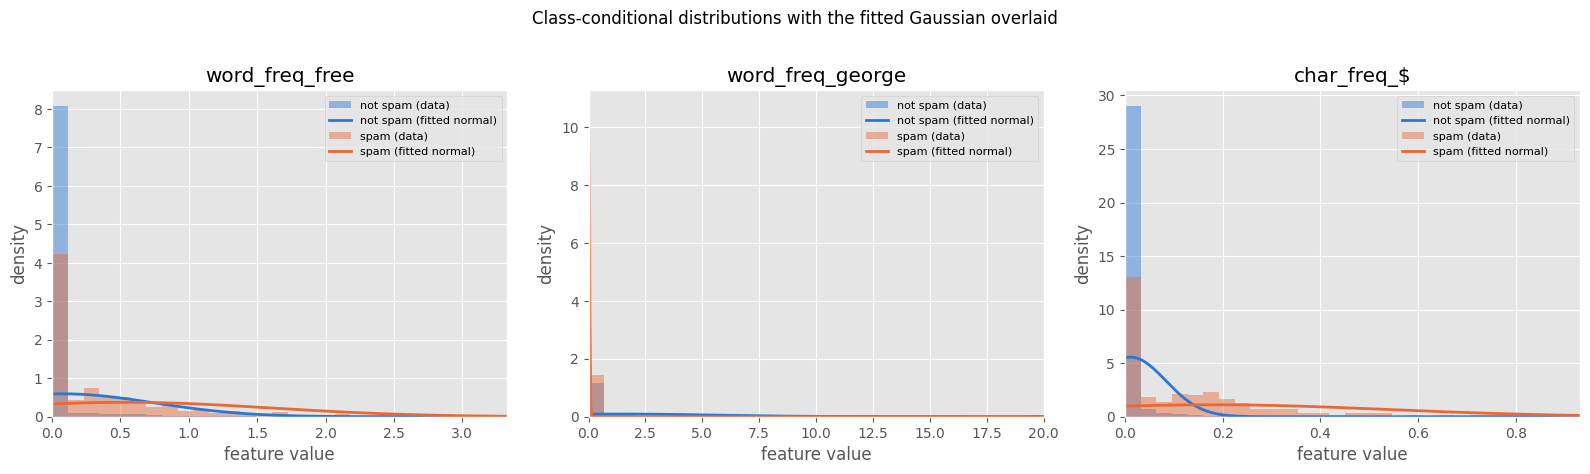

word_freq_free       zero in 91.0% of ham, 44.3% of spam
word_freq_george     zero in 72.0% of ham, 99.5% of spam
char_freq_$          zero in 89.5% of ham, 37.8% of spam


In [8]:
show_feats = ['word_freq_free', 'word_freq_george', 'char_freq_$']
show_idx = [feature_names.index(f) for f in show_feats]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, j, name in zip(axes, show_idx, show_feats):
    hi = np.percentile(X_train[:, j], 99.0)
    hi = hi if hi > 0 else X_train[:, j].max()
    bins = np.linspace(0, hi, 30)
    grid = np.linspace(0, hi, 400)

    for c, colour, lab in [(0, BLUE, 'not spam'), (1, ORANGE, 'spam')]:
        vals = X_train[y_train == c, j]
        ax.hist(vals, bins=bins, density=True, alpha=0.45, color=colour, label=lab + ' (data)')
        mu, var = gnb.mean[c, j], gnb.var[c, j]
        pdf = np.exp(-0.5 * (grid - mu) ** 2 / var) / np.sqrt(2.0 * np.pi * var)
        ax.plot(grid, pdf, color=colour, lw=2.0, label=lab + ' (fitted normal)')

    ax.set_title(name)
    ax.set_xlabel('feature value')
    ax.set_ylabel('density')
    ax.set_xlim(0, hi)
    ax.legend(fontsize=8)

fig.suptitle('Class-conditional distributions with the fitted Gaussian overlaid', y=1.02)
plt.tight_layout()
plt.show()

for j, name in zip(show_idx, show_feats):
    z0 = np.mean(X_train[y_train == 0, j] == 0)
    z1 = np.mean(X_train[y_train == 1, j] == 0)
    print('%-20s zero in %.1f%% of ham, %.1f%% of spam' % (name, 100 * z0, 100 * z1))

## Why prediction runs in log space

Take one test email and evaluate the 57 Gaussian densities $P(x_j \mid y=\text{spam})$ under the fitted model. Each is a plain float. Multiplying them in order gives the running product below.

float64 cannot represent a positive number smaller than about $2.2 \times 10^{-308}$, and anything below that rounds to exactly `0.0`. Once the running product hits zero it stays zero, and every remaining feature is ignored — the score for that class is `0.0` regardless of what the rest of the email says. Both classes end up at `0.0`, so `argmax` picks whichever index comes first and the classifier is reduced to a coin flip.

The log-space form has no such problem. Instead of computing each density and taking its log, the implementation computes the log-density analytically, $-\tfrac{1}{2}\log(2\pi\sigma^2) - (x-\mu)^2/(2\sigma^2)$, so `exp` is never called and no intermediate value underflows. The running sum of logs stays a comfortable, ordinary number.

The cell below prints the two running quantities side by side and the chart plots them: the raw product on a log scale, collapsing to zero part-way through, against the log-sum descending in a straight, finite line.

In [9]:
row = 0
x_row = X_test[row]
c_spam = 1

mu_s, var_s = gnb.mean[c_spam], gnb.var[c_spam]

# per-feature densities computed the naive way, then multiplied
dens = np.exp(-0.5 * (x_row - mu_s) ** 2 / var_s) / np.sqrt(2.0 * np.pi * var_s)
# per-feature log-densities computed analytically, never exponentiated
log_dens = -0.5 * np.log(2.0 * np.pi * var_s) - 0.5 * (x_row - mu_s) ** 2 / var_s

running_prod = np.cumprod(dens)
running_logsum = np.cumsum(log_dens)

zero_at = np.argmax(running_prod == 0.0) + 1 if np.any(running_prod == 0.0) else None

print('true label of test row %d: %d' % (row, y_test[row]))
print('float64 smallest normal positive: %.4e' % np.finfo(np.float64).tiny)
print()
print(' j   density            running product     running log-sum')
for j in list(range(0, 6)) + [zero_at - 3, zero_at - 2, zero_at - 1, zero_at, zero_at + 1, 56]:
    print('%3d  %-18.6e %-19.6e %.4f' % (j, dens[j], running_prod[j], running_logsum[j]))
print()
print('running product first hits exactly 0.0 at feature %d of 57' % zero_at)
print('final raw product   : %.6e' % running_prod[-1])
print('final log-sum       : %.6f  (finite)' % running_logsum[-1])
with np.errstate(divide='ignore'):
    print('log of raw product  :', np.log(running_prod[-1]))
print()
n_under = int(np.sum(np.prod(np.exp(-0.5 * (X_test - mu_s) ** 2 / var_s)
                             / np.sqrt(2.0 * np.pi * var_s), axis=1) == 0.0))
print('%d of %d test emails underflow to exactly 0.0 under the naive product'
      % (n_under, X_test.shape[0]))

true label of test row 0: 0
float64 smallest normal positive: 2.2251e-308

 j   density            running product     running log-sum
  0  1.196402e+00       1.196402e+00        0.1793
  1  1.047669e+00       1.253433e+00        0.2259
  2  5.768255e-01       7.230119e-01        -0.3243
  3  1.803299e-01       1.303807e-01        -2.0373
  4  8.792846e-02       1.146417e-02        -4.4685
  5  1.087555e+00       1.246792e-02        -4.3846
 28  2.809258e+01       1.698164e-29        -66.2454
 29  5.632109e+00       9.564244e-29        -64.5169
 30  0.000000e+00       0.000000e+00        -1210.9005
 31  2.278391e+01       0.000000e+00        -1207.7745
 32  3.761263e+00       0.000000e+00        -1206.4497
 56  4.549435e-04       0.000000e+00        -3734.9591

running product first hits exactly 0.0 at feature 31 of 57
final raw product   : 0.000000e+00
final log-sum       : -3734.959095  (finite)
log of raw product  : -inf

227 of 921 test emails underflow to exactly 0.0 under the nai

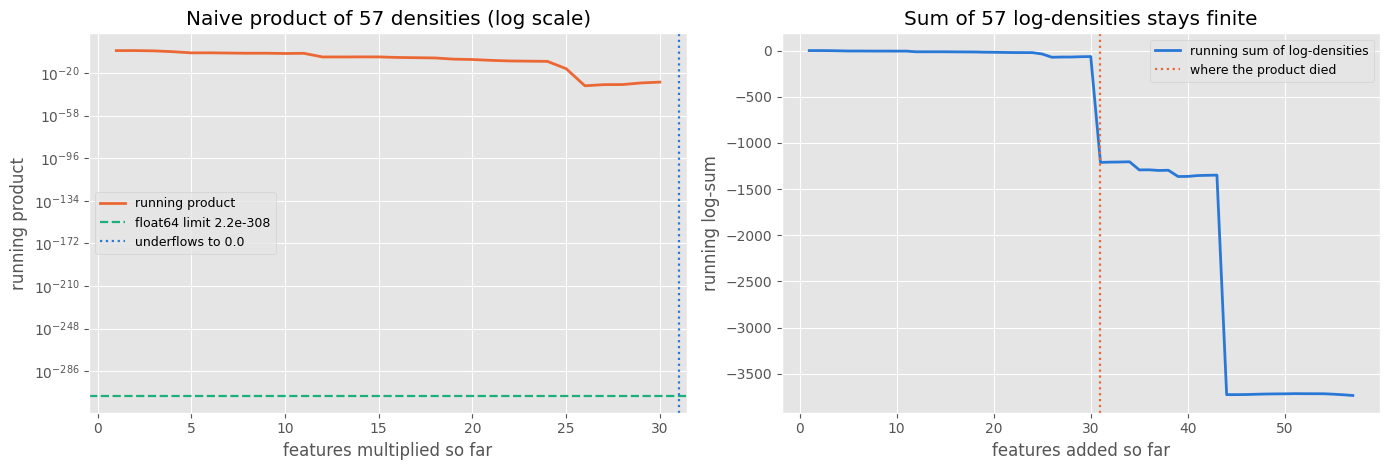

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

steps = np.arange(1, 58)
safe = np.where(running_prod > 0, running_prod, np.nan)
axes[0].semilogy(steps, safe, color=ORANGE, lw=2, label='running product')
axes[0].axhline(np.finfo(np.float64).tiny, color=GREEN, ls='--', lw=1.6,
                label='float64 limit 2.2e-308')
axes[0].axvline(zero_at, color=BLUE, ls=':', lw=1.6, label='underflows to 0.0')
axes[0].set_title('Naive product of 57 densities (log scale)')
axes[0].set_xlabel('features multiplied so far')
axes[0].set_ylabel('running product')
axes[0].legend(fontsize=9)

axes[1].plot(steps, running_logsum, color=BLUE, lw=2, label='running sum of log-densities')
axes[1].axvline(zero_at, color=ORANGE, ls=':', lw=1.6, label='where the product died')
axes[1].set_title('Sum of 57 log-densities stays finite')
axes[1].set_xlabel('features added so far')
axes[1].set_ylabel('running log-sum')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Most discriminative features

For the Bernoulli model the evidence a single word carries is the log ratio of its presence probability under the two classes:

$$\text{score}_j = \log \frac{P(x_j = 1 \mid \text{spam})}{P(x_j = 1 \mid \text{ham})}$$

A positive score means the word is more common in spam and pushes the sum towards the spam class; a negative score pushes the other way. Because both $\theta$ values are Laplace-smoothed, the ratio is always finite even for words that never appear in one class.

The chart shows the twelve strongest features in each direction, coloured by which class they favour.

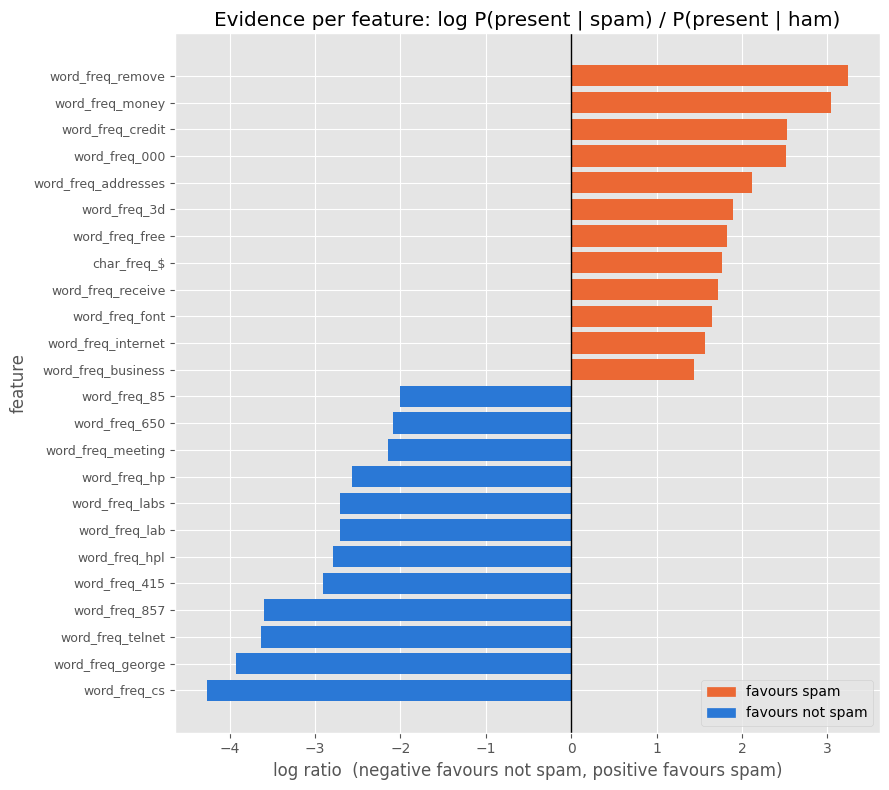

strongest spam indicators:
  word_freq_remove             +3.242
  word_freq_money              +3.046
  word_freq_credit             +2.530
  word_freq_000                +2.520
  word_freq_addresses          +2.123
  word_freq_3d                 +1.895
  word_freq_free               +1.822
  char_freq_$                  +1.771
strongest not-spam indicators:
  word_freq_cs                 -4.260
  word_freq_george             -3.921
  word_freq_telnet             -3.637
  word_freq_857                -3.597
  word_freq_415                -2.910
  word_freq_hpl                -2.793
  word_freq_lab                -2.712
  word_freq_labs               -2.709


In [11]:
log_ratio = bnb.log_theta[1] - bnb.log_theta[0]
order = np.argsort(log_ratio)

top_n = 12
picked = np.concatenate([order[:top_n], order[-top_n:]])
vals = log_ratio[picked]
names_picked = [feature_names[j] for j in picked]
colours = [BLUE if v < 0 else ORANGE for v in vals]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(np.arange(len(picked)), vals, color=colours)
ax.set_yticks(np.arange(len(picked)))
ax.set_yticklabels(names_picked, fontsize=9)
ax.axvline(0, color='k', lw=1)
ax.set_title('Evidence per feature: log P(present | spam) / P(present | ham)')
ax.set_xlabel('log ratio  (negative favours not spam, positive favours spam)')
ax.set_ylabel('feature')
handles = [plt.Rectangle((0, 0), 1, 1, color=ORANGE), plt.Rectangle((0, 0), 1, 1, color=BLUE)]
ax.legend(handles, ['favours spam', 'favours not spam'], loc='lower right')
plt.tight_layout()
plt.show()

print('strongest spam indicators:')
for j in order[::-1][:8]:
    print('  %-28s %+.3f' % (feature_names[j], log_ratio[j]))
print('strongest not-spam indicators:')
for j in order[:8]:
    print('  %-28s %+.3f' % (feature_names[j], log_ratio[j]))

## Evaluation

`confusion_counts` returns the four cell counts treating spam (class 1) as positive, and `evaluate` turns them into accuracy, precision and recall:

$$\text{accuracy} = \frac{TP + TN}{N}, \qquad \text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}$$

For a spam filter the two error types are not equally bad. A **false negative** is a spam email that reaches the inbox: a small annoyance, the user deletes it. A **false positive** is a legitimate email silently filed as spam: potentially an invoice, a job offer or a message from a colleague that the user never sees. Precision on the spam class is $TP/(TP+FP)$, so it is precisely the quantity that falls when false positives rise — it is the number to watch here, ahead of accuracy.

In [12]:
def confusion_counts(y_true, y_pred):
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    return tp, tn, fp, fn


def evaluate(y_true, y_pred):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)
    acc = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return acc, prec, rec


pred_gauss = gnb.predict(X_test)
pred_bern = bnb.predict(X_test)

acc_g, prec_g, rec_g = evaluate(y_test, pred_gauss)
acc_b, prec_b, rec_b = evaluate(y_test, pred_bern)

print('%-12s %9s %9s %9s' % ('model', 'accuracy', 'precision', 'recall'))
print('%-12s %9.4f %9.4f %9.4f' % ('Gaussian', acc_g, prec_g, rec_g))
print('%-12s %9.4f %9.4f %9.4f' % ('Bernoulli', acc_b, prec_b, rec_b))
print()
print('Gaussian  tp/tn/fp/fn:', confusion_counts(y_test, pred_gauss))
print('Bernoulli tp/tn/fp/fn:', confusion_counts(y_test, pred_bern))
print()
print('train accuracy Gaussian :', round(evaluate(y_train, gnb.predict(X_train))[0], 4))
print('train accuracy Bernoulli:', round(evaluate(y_train, bnb.predict(X_train))[0], 4))

model         accuracy precision    recall
Gaussian        0.8274    0.7117    0.9624
Bernoulli       0.8838    0.9027    0.7984

Gaussian  tp/tn/fp/fn: (358, 404, 145, 14)
Bernoulli tp/tn/fp/fn: (297, 517, 32, 75)

train accuracy Gaussian : 0.8082
train accuracy Bernoulli: 0.887


## Confusion matrices

Rows are the true class, columns the prediction, counts annotated in each cell. The top-right cell of each matrix is the false-positive count — legitimate mail thrown away — and it is where the two models differ most sharply.

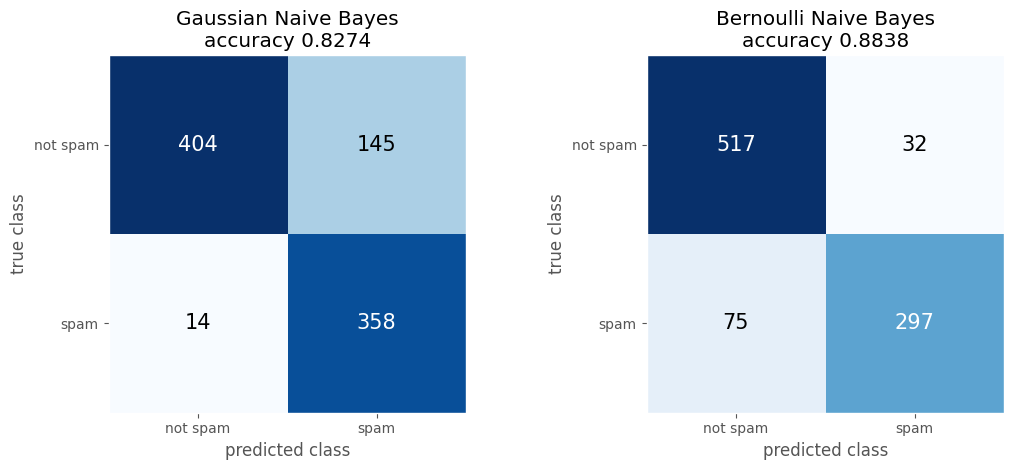

false positives (real mail marked spam) - Gaussian : 145
false positives (real mail marked spam) - Bernoulli: 32


In [13]:
def confusion_matrix(y_true, y_pred):
    m = np.zeros((2, 2), dtype=int)
    for t in (0, 1):
        for p in (0, 1):
            m[t, p] = int(np.sum((y_true == t) & (y_pred == p)))
    return m


cms = [confusion_matrix(y_test, pred_gauss), confusion_matrix(y_test, pred_bern)]
titles = ['Gaussian Naive Bayes', 'Bernoulli Naive Bayes']
tick_labels = ['not spam', 'spam']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, cm, title in zip(axes, cms, titles):
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=15,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(tick_labels)
    ax.set_title(title + '\naccuracy %.4f' % ((cm[0, 0] + cm[1, 1]) / cm.sum()))
    ax.set_xlabel('predicted class')
    ax.set_ylabel('true class')
    ax.grid(False)

plt.tight_layout()
plt.show()

print('false positives (real mail marked spam) - Gaussian : %d' % cms[0][0, 1])
print('false positives (real mail marked spam) - Bernoulli: %d' % cms[1][0, 1])

## Gaussian against Bernoulli

The grouped bar chart puts accuracy, spam precision and spam recall side by side.

The Bernoulli model wins on accuracy and wins decisively on precision. The Gaussian model has higher recall — it catches more of the spam — but it does so by labelling far more legitimate mail as spam, and for a spam filter that trade is the wrong way round. Its high recall is not a virtue here; it is a symptom of a model biased towards predicting the positive class.

The reason is the histograms above. The Gaussian model is fitting normal curves to zero-inflated, right-skewed percentage columns, so its likelihood estimates are wrong in a way that consistently misranks the classes for a subset of emails. The Bernoulli model asks a question the data can actually answer — did this word occur — and the answer to that question is close to a genuine Bernoulli draw. The simpler distributional assumption is the better match, which is why the less expressive model wins.

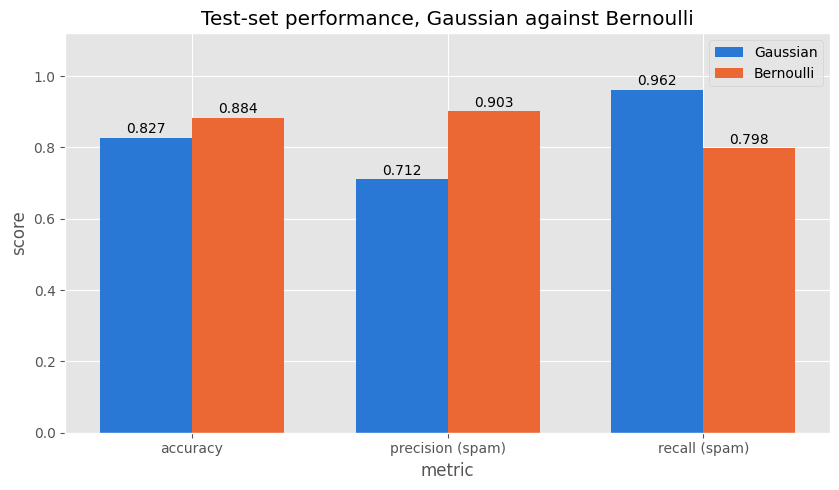

In [14]:
metrics_g = [acc_g, prec_g, rec_g]
metrics_b = [acc_b, prec_b, rec_b]
metric_names = ['accuracy', 'precision (spam)', 'recall (spam)']

pos = np.arange(3)
w = 0.36

fig, ax = plt.subplots(figsize=(8.5, 5))
b1 = ax.bar(pos - w / 2, metrics_g, w, color=BLUE, label='Gaussian')
b2 = ax.bar(pos + w / 2, metrics_b, w, color=ORANGE, label='Bernoulli')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                '%.3f' % b.get_height(), ha='center', fontsize=10)
ax.set_xticks(pos)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.12)
ax.set_title('Test-set performance, Gaussian against Bernoulli')
ax.set_xlabel('metric')
ax.set_ylabel('score')
ax.legend()
plt.tight_layout()
plt.show()

## Effect of the smoothing parameter

$\alpha$ controls how much probability mass Laplace smoothing moves away from the observed counts. At $\alpha \to 0$ the estimates are the raw frequencies and any word absent from a class gives $\theta = 0$, which is $-\infty$ in log space. As $\alpha$ grows, every $\theta_{jy}$ is pulled towards $1/2$ and the differences between the classes shrink, so the model loses the signal it was built on.

The sweep below refits `Bernoulli_Naive_Bayes` across several orders of magnitude of $\alpha$ and plots test accuracy, precision and recall. Performance is flat over a wide middle range and then degrades steadily once $\alpha$ becomes comparable to the class sizes — smoothing is a safeguard against zero counts, not a parameter that needs careful tuning.

alpha 0.001    accuracy 0.8860  precision 0.9083  recall 0.7984


alpha 0.010    accuracy 0.8849  precision 0.9055  recall 0.7984
alpha 0.100    accuracy 0.8838  precision 0.9027  recall 0.7984


alpha 0.500    accuracy 0.8838  precision 0.9027  recall 0.7984
alpha 1.000    accuracy 0.8838  precision 0.9027  recall 0.7984
alpha 2.000    accuracy 0.8773  precision 0.8960  recall 0.7876
alpha 5.000    accuracy 0.8773  precision 0.8960  recall 0.7876
alpha 10.000   accuracy 0.8730  precision 0.8899  recall 0.7823
alpha 50.000   accuracy 0.8599  precision 0.8738  recall 0.7634
alpha 100.000  accuracy 0.8480  precision 0.8648  recall 0.7392
alpha 500.000  accuracy 0.8154  precision 0.9040  recall 0.6075
alpha 1000.000 accuracy 0.7828  precision 0.9175  recall 0.5081


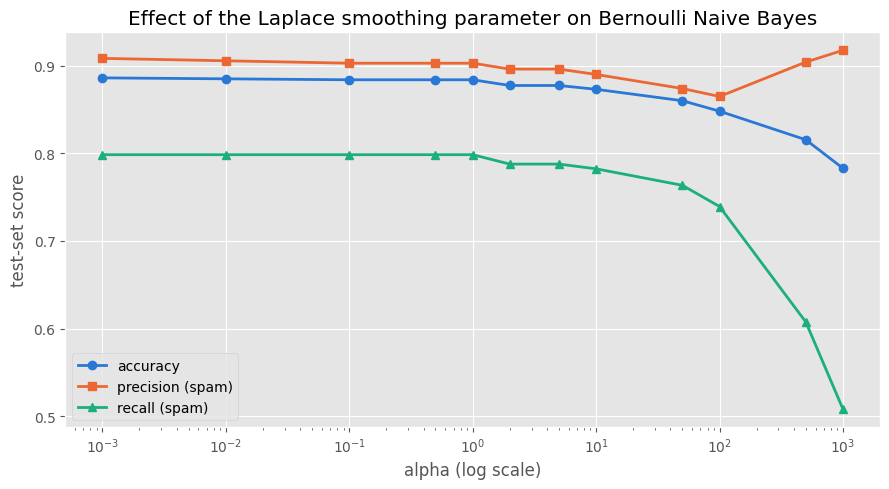


best accuracy 0.8860 at alpha = 0.001


In [15]:
alphas = np.array([1e-3, 1e-2, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0])
sweep = np.zeros((len(alphas), 3))

for i, a in enumerate(alphas):
    model = Bernoulli_Naive_Bayes(alpha=a).fit(X_train, y_train)
    sweep[i] = evaluate(y_test, model.predict(X_test))
    print('alpha %-8.3f accuracy %.4f  precision %.4f  recall %.4f'
          % (a, sweep[i, 0], sweep[i, 1], sweep[i, 2]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(alphas, sweep[:, 0], 'o-', color=BLUE, lw=2, label='accuracy')
ax.semilogx(alphas, sweep[:, 1], 's-', color=ORANGE, lw=2, label='precision (spam)')
ax.semilogx(alphas, sweep[:, 2], '^-', color=GREEN, lw=2, label='recall (spam)')
ax.set_title('Effect of the Laplace smoothing parameter on Bernoulli Naive Bayes')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('test-set score')
ax.legend()
plt.tight_layout()
plt.show()

best = int(np.argmax(sweep[:, 0]))
print()
print('best accuracy %.4f at alpha = %g' % (sweep[best, 0], alphas[best]))

## Summary

Fitting a Naive Bayes classifier is counting. `Gaussian_Naive_Bayes.fit` computes a mean and a variance per feature per class; `Bernoulli_Naive_Bayes.fit` computes a smoothed presence probability per feature per class. Both are closed-form maximum-likelihood estimates evaluated in a single pass, and both finish in milliseconds. Nothing is optimised iteratively.

The conditional-independence assumption is plainly false on email text, and the posteriors it produces are not trustworthy as probabilities. It works anyway because the decision rule only reads the argmax, and correlated evidence usually distorts both class scores in a direction that leaves their ordering intact.

Prediction has to happen in log space. The raw product of 57 Gaussian densities underflows to exactly `0.0` for a large share of the test set, which destroys the comparison between classes entirely; computing the log-density analytically and summing keeps every value in an ordinary numeric range.

The two guards do different jobs. The variance floor stops a class-conditionally constant column from dividing by zero. Laplace smoothing stops an unseen word from zeroing an entire class score, which in log space would be $-\infty$.

On this dataset Bernoulli beats Gaussian. The word-frequency columns are zero-inflated percentages that a normal curve fits badly, and the Gaussian model pays for it with a large false-positive count — the error a spam filter can least afford. Discarding the magnitudes and keeping only word presence matches the data's real shape, and the cruder model is the more accurate one.